# 28 · Multi-Agent Debate — argue, then vote

> **TL;DR.** N agents (same LLM, different personas) answer the question; each round they see the others' prior answers and revise; after K rounds, Python majority-votes.
>
> **Reach for it when** the task is hard enough that a single chain-of-thought is unreliable AND there's value in agents *seeing each other's reasoning* (which Self-Consistency nb 21 lacks).

| Property | Value |
|---|---|
| Origin | Du et al., *Improving Factuality and Reasoning in Language Models through Multiagent Debate* (2023). [arXiv:2305.14325](https://arxiv.org/abs/2305.14325) |
| Vote | Python `Counter.most_common(1)` on last-round answers — deterministic-picker |
| Cost | `n_agents × n_rounds` LLM calls |

**Why this is different from Self-Consistency (nb 21).** SC samples N independent paths blind to each other. Debate's agents *see prior-round answers* and can update — letting an initially-wrong agent change its mind when confronted with stronger arguments. The cross-pollination is the whole point.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> R1[ROUND 1<br/><sub>N agents answer independently</sub>]
    R1 --> R2[ROUND 2<br/><sub>each agent sees others' R1 answers, revises</sub>]
    R2 --> R3[…]
    R3 --> V[VOTE<br/><sub>Counter on last round's answers</sub>]
    V --> Z([modal answer])

    style R1 fill:#e3f2fd,stroke:#1976d2
    style R2 fill:#fff3e0,stroke:#f57c00
    style V fill:#e8f5e9,stroke:#388e3c
```

## 3 · Theory

### 3.0 · The promise

If 2 of 3 agents are wrong in their first instinct, simple majority vote (Self-Consistency) returns the wrong answer. Debate lets the *one* correct agent expose their reasoning; round 2 reads it and the originally-wrong agents update. The vote in round-2 may now be 3-of-3 correct.

### 3.1 · The risk

The opposite also happens: the *one* wrong agent argues louder, and a previously-correct agent switches sides. The handoff §7 deterministic-picker discipline doesn't fix this — the picker (Counter) just tallies whatever the agents end up at.

Mitigation: require *both* "answer" AND "critique_of_others" per response, so an agent has to engage with arguments rather than just restate. Schema enforces this.

### 3.2 · Where this sits

| Pattern | Voter independence |
|---|---|
| [Self-Consistency (nb 21)](./21_self_consistency.ipynb) | Independent (no cross-talk) |
| [Ensemble (nb 13)](./13_ensemble.ipynb) | Different roles, vote once |
| **Debate (this nb)** | **Same role, K rounds of cross-talk** |
| Council-of-judges (extension) | Different roles + K rounds |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Debate
from agentic_architectures.ui import print_md, print_header

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)
print_header(f"LLM: {llm.model}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.debate import _DebateResponse, Debate
import json
print('--- _DebateResponse schema ---')
print(json.dumps(_DebateResponse.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- Default agent personas ---')
for i, p in enumerate(Debate.AGENT_PERSONAS):
    print(f'  [{i}] {p}')

--- _DebateResponse schema ---
{
  "description": "One agent's per-round output.",
  "properties": {
    "answer": {
      "description": "JUST the final answer in the requested format \u2014 no preface, no critique here. (Critiques go in the other field.)",
      "title": "Answer",
      "type": "string"
    },
    "critique_of_others": {
      "description": "2-3 sentences engaging with the other agents' prior answers \u2014 ...

--- Default agent personas ---
  [0] You are Agent A: rigorous, demands step-by-step reasoning before committing to an answer.
  [1] You are Agent B: skeptical, actively looks for counterexamples and edge cases.
  [2] You are Agent C: pragmatic, focuses on which answer best fits all available evidence.


## 7 · Build the graph

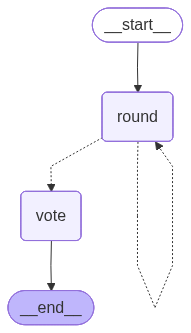

In [3]:
from IPython.display import Image, display
arch = Debate(llm=llm, n_agents=3, n_rounds=2, sample_temperature=0.7)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — Sally-siblings trick problem

Same trap as nb 21 Self-Consistency. With debate, we'd expect agents who slip on round 1 to be corrected by their peers in round 2.

In [4]:
TASK = (
    "Sally is a girl with 3 brothers. Each of her brothers has 2 sisters. "
    "How many sisters does Sally have? Return only the integer answer."
)
EXPECTED = "1"

r = arch.run(TASK)
print(f"FINAL_ANSWER: {r.output}")
print(f"EXPECTED: {EXPECTED}")
print(f"MATCH: {r.output.strip() == EXPECTED}")
print(f"CONVERGENCE: {r.metadata['convergence']}")
print(f"ROUND_UNIQUE_COUNTS: {r.metadata['round_unique_answer_count']}")
print(f"FINAL_TALLY: {r.metadata['final_tally']}")
print()
for round_idx, rd in enumerate(r.metadata['rounds'], 1):
    print(f"--- ROUND {round_idx} ---")
    for resp in rd:
        print(f"  Agent {chr(65+resp['agent_id'])}: answer={resp['answer']!r}")
        print(f"    critique: {resp['critique'][:200]}")

FINAL_ANSWER: 0
EXPECTED: 1
MATCH: False
CONVERGENCE: partial
ROUND_UNIQUE_COUNTS: [1, 2]
FINAL_TALLY: {'0': 2, '2': 1}

--- ROUND 1 ---
  Agent A: answer='2'
    critique: (round 1 — no prior answers)
  Agent B: answer='2'
    critique: (round 1 — no prior answers)
  Agent C: answer='2'
    critique: (round 1 — no prior answers)
--- ROUND 2 ---
  Agent A: answer='0'
    critique: All agents agreed that Sally has 2 sisters in the prior round, but I disagree. Since each of Sally's brothers has 2 sisters, and one of them must be Sally herself, it means that there is only 1 other 
  Agent B: answer='0'
    critique: I disagree with Agents A and C, who both said Sally has 2 sisters. Since each of her brothers has 2 sisters, and one of those sisters must be Sally herself, it means that there is only one other siste
  Agent C: answer='2'
    critique: Agents A and B also concluded that Sally has 2 sisters, which aligns with my own analysis that each of her brothers having 2 sisters implies S

## 9 · What we just observed

The cells above ran a 3-agent × 2-round debate on the Sally-siblings trick problem.

### 9.1 · Summary

- **Winner**: `0` — ❌ differs from expected `1`
- **Convergence**: partial
- **Unique answers per round**: [1, 2]
- **Final tally**: {'0': 2, '2': 1}

### 9.2 · Per-round agent responses

#### Round 1

| Agent | Answer | Critique |
|---|---|---|
| Agent A | `2` | (round 1 — no prior answers) |
| Agent B | `2` | (round 1 — no prior answers) |
| Agent C | `2` | (round 1 — no prior answers) |

#### Round 2

| Agent | Answer | Critique |
|---|---|---|
| Agent A | `0` | All agents agreed that Sally has 2 sisters in the prior round, but I disagree. Since each of Sally's brothers has 2 sist… |
| Agent B | `0` | I disagree with Agents A and C, who both said Sally has 2 sisters. Since each of her brothers has 2 sisters, and one of … |
| Agent C | `2` | Agents A and B also concluded that Sally has 2 sisters, which aligns with my own analysis that each of her brothers havi… |

### 9.3 · Patterns surfaced in this run

- **⚠️ No full convergence** — 2 unique answers in the final round; majority vote decided. Consider more rounds or a judge LLM.

- **❌ Majority vote was wrong** (got `0`, expected `1`). Group-think can fail; pair with verification.

### 9.4 · The takeaway

Debate's value is in `ROUND_UNIQUE_COUNTS`: a `[2, 1]` sequence means agents disagreed in round 1, then converged by round 2 — that's the cross-talk paying off. A `[1, 1]` sequence means everyone agreed from the start (debate wasted N×K calls); `[2, 2]` means no convergence and majority vote decided based on first-round noise.

The deterministic-picker is `Counter.most_common(1)` on the last round — same pattern as Self-Consistency (nb 21), but the votes were *informed by* peers' arguments, not independent.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Group-think convergence on wrong answer** | One loud agent shifts the others | Diverse personas; weight agent influence by confidence |
| **No convergence** | Agents stubborn; final tally split | Add round 3+; or escalate to human judge |
| **Cost** | `agents × rounds` calls per task | Cap agents=3, rounds=2 for most tasks |

Extensions: (1) heterogeneous LLMs per agent (Llama + Qwen-Thinking + GPT), (2) weighted-by-confidence vote, (3) judge-LLM that picks the best argument rather than majority vote.

Reference: Du et al. 2023 — [arXiv:2305.14325](https://arxiv.org/abs/2305.14325)